## DSAI4205 Big Data Analytics
## Assignment 1 (10%), Term 2, 2025-2026

#### **Instructions for the assignment**:
* Follow the provided instructions to solve the questions.
* Please save the report and named as DSAI4205Assignment1_{your student_id}.ipynb (e.g., if student_id is 1234567, then the file's name is DSAI4205Assignment1_1234567.ipynb).

* Submit the notebook file to the blackboard. The submission due date is **<font color='red'>24 Feb 2026 23:55</font>**

<font color='red'>**You should complete the assignment on your own. You must uphold academic integrity and academic honesty in the assignment. You can be subject to disciplinary action if proven to have acted against academic integrity and academic honesty.**</font>

### Q1: Distributed Sensor Calibration with Dask (20 marks)

You have a massive Dask array representing sensor readings (Data) from a global network. However, each sensor (represented by one "block" of the array) has a different calibration "Gain" factor that must be applied. These factors are stored in a separate, smaller Dask array (Weights).

**Raw Data:**   
Create a $(1000\times 1000)$ Dask array of floats, chunked into $(100,100)$ blocks. This results in a $(10\times 10)$ grid of blocks (100 blocks total).
We use a Normal (Gaussian) Distribution for sensor readings (mean=10, std=1.0). In physics and engineering, most natural signals and background noise follow a "Bell Curve," where values cluster around a central truth with occasional small deviations.

**The Weights:**    
Create a $(10\times 10)$ Dask array of floats, chunked into $((1,1))$ blocks. Crucially, this array also has exactly 100 blocks total. We use a Uniform Distribution for calibration factors (0.9 to 1.1). This represents a "Tolerance Window." Manufacturers guarantee that a sensor’s gain will fall within a strict \(\pm 10\%\) range, but any value within that window is equally likely to occur.

<font color="red">Task 1.1: Setup the Data array and weight array.</font>

In [52]:
import dask.array as da
import numpy as np

raw_data = ...
weights = ...

<font color="red">Task 1.2: Write a function apply_calibration(data_block, weight_block, block_info=None) that multiplies the entire data_block by the single scalar value in weight_block.</font>

- <font color="red">Add a global counter or a print statement inside your function. Run map_blocks without the dtype argument, then run it with the dtype argument. Why does the first version execute your function more times than the second? How to adjust the map_blocks function to run exactly 100 times ?</font>

- <font color="red">Please explain why Dask allows you to pass two arrays of different total shapes $(1000\times 1000)$ vs $(10\times 10)$ into the same map_blocks call. Please justify your answer by using block_info and provide examples to support your answer.</font>

In [54]:
counter = 0

def apply_calibration(data_block, weight_block, block_info=None):
    ...

<font color="red">Please provide your explanation of Task 1.2 by editing this cell.</font>

**First bullet points**

...

**Second bullet points**

...

<font color="red">Task 1.3: What error does Dask produce if the Weights array was a 1D array of 100 elements ? Please provide the fix.</font>

In [1]:
#Task 1.3.1: construct the 1D array of 100 elements
...

#Task 1.3.2: call the map_block function to observe the error
...

#Task 1.3.3: provide your fix
...

<font color="red">Please provide your explanation of Task 1.3 by editing this cell.</font>

<font color="red">**Answer**: 

### Q2: Parallel Diffusion Simulation (80 marks)

In this section, we will examine how to use the `map_overlap()` function to simulate a parallel 2D diffusion.

Imagine you have a large grid representing a beaker of still water. In the middle, you gently drop a single drop of ink (a "hot spot" of high concentration).

- Initially: One spot has a value of 100 (pure ink), and everything else is 0 (Clear water).
- Over Time: The ink particles move randomly. They travel from where there are many particles to where there are fewer particles.
- Eventually: The ink spreads out until the entire beaker has the same, low-level concentration. This state is called equilibrium, and the water is a uniform blue.

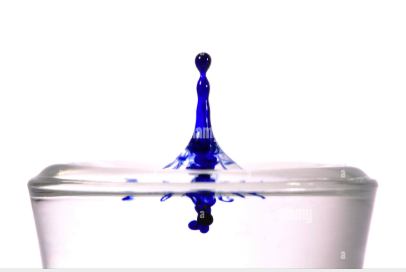

In a computer simulation, we don't track individual particles. Instead, we use a Grid (Matrix). To simulate spreading, we apply a simple rule to every cell in the grid simultaneously:

To calculate the value of a cell (Center) for the next second of time, we look at its four immediate neighbors: North (N), South (S), East (E), and West (W). The change in the center cell is determined by the net difference between it and its neighbors:

The change in the center cell is determined by the net difference between it and its neighbors:

$\text{Change}=(N+S+E+W)-4\times Center$

- If the neighbors are "fuller" than the center: The sum $(N+S+E+W)$ will be larger than $(4\times Center)$, resulting in a positive change. **The center value goes up**.

- If the center is "fuller" than its neighbors: The change is negative. **The center value goes down**.

For a stable simulation update, it needs a coefficient to scale the change over a small time step. The full equation for the next value of the center cell is:

$ v_{i,j}^{next}=v_{i,j}^{current}+\gamma \times (N+S+E+W-4\times v_{i,j}^{current})$

where
- $v_{i,j}$ is the value of cell (i,j),
- $\gamma$ is the diffusion coefficient, should be less than 0.25 for stability
- $N,S,E,W$ are the FOUR immediate neighbors

<font color="red">Task 2.1: Setup Dask Array.
Create a $(20\times 20)$ Dask array filled with zeros. To visualize the diffusion simulation more effectively, we will set the indices from 7 to 12 in both the rows and columns to 100.</font>

In [2]:
# Task 2.1: Initialize the grid (start with a NumPy array with the hot spot, then convert to Dask)
...

**The code below is provided to visualize the diffusion process at a specific moment in time.**

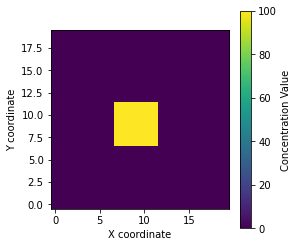

In [132]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_diffusion(dask_array, title):
    """
    Computes the Dask array and plots it as a heatmap.
    """
    # Compute the array to bring it into local memory as a NumPy array
    result_np = dask_array.compute()

    plt.figure(figsize=(4, 4))
    plt.imshow(result_np, cmap='viridis', vmin=0, vmax=100, origin='lower')

    plt.colorbar(label='Concentration Value')
    plt.title(title)
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.show()

visualize_diffusion(grid, '')


<font color='red'>Please follow the TODO instructions from sections 2.2 to 2.6 to finish this question.</font>

In [136]:
#Task 2.2: Create a function to compute the sum of the neighbors' weights for the coordinates (i,j) within the chunk.

def computeNeighborWeights(chunk, i, j):
    ...

<font color="red">**In Task 2.3, it is a must to utilize a nested for loop to update each element**</font>

In [116]:
#Task 2.3: Implement the update_diffusion function to update the values for each individual cell and return the next state.

def update_diffusion(block=None, core_dims=None, gamma=0.05, block_info=None):
    ...



<font color='red'>Task 2.4: To demonstrate your understanding of the logic in the code you provided above, please explain the logic of update_diffusion in your own words.</font>

<font color="red">Please provide your answer by editing this cell.</font>

<font color="red">**Answer**: 

In [4]:
#TODO 2.5: Use the map_overlap Function to invoke update_diffusion and
#          Compute the Next 50 Iterations of the diffusion on the grid in Parallel.
#          Please show the results by plotting the graph using matplotlib for every 5 iterations 

...

<font color='red'>Task 2.6: Please explain the parameters (`depth`, `boundary`, `trim`) with **Examples**:
- For instance, describe what happens to the chunk with different values for depth and boundary. (Using a single chunk for illustration is acceptable.)
- How trimming affects your final merged results. 

<font color="red">Please provide your answer by editing this cell.</font>

<font color="red">**Answer**: 

**You've reached the end of the assignment. Don't forget to upload it to Blackboard.**